In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [3]:
data={
    "Name":["Anuj","Diya","Anuja","Chinmay","Husain","Sufiyan","Aryan","Sakshi","Riya","Amit"],
    "Maths":[83,95,np.nan,96,88,80,72,500,92,85],
    "Science":[95,97,89,np.nan,82,76,90,88,450,96],
    "English":[90,88,93,75,np.nan,85,92,83,95,91],
    "Attendance":[81,79,85,93,88,np.nan,78,82,91,80]
}

df=pd.DataFrame(data)

print("Dataset: ")
print(df)

Dataset: 
      Name  Maths  Science  English  Attendance
0     Anuj   83.0     95.0     90.0        81.0
1     Diya   95.0     97.0     88.0        79.0
2    Anuja    NaN     89.0     93.0        85.0
3  Chinmay   96.0      NaN     75.0        93.0
4   Husain   88.0     82.0      NaN        88.0
5  Sufiyan   80.0     76.0     85.0         NaN
6    Aryan   72.0     90.0     92.0        78.0
7   Sakshi  500.0     88.0     83.0        82.0
8     Riya   92.0    450.0     95.0        91.0
9     Amit   85.0     96.0     91.0        80.0


In [5]:
print("Missing values: ")
print(df.isnull().sum())
#replace missing values with median
df['Maths'].fillna(df['Maths'].median())
df['Science'].fillna(df['Science'].median())
df['English'].fillna(df['English'].median())
df['Attendance'].fillna(df['Attendance'].median())

print("After handling missing values:")
print(df)

Missing values: 
Name          0
Maths         0
Science       0
English       0
Attendance    0
dtype: int64
After handling missing values:
      Name  Maths  Science  English  Attendance
0     Anuj   83.0     95.0     90.0        81.0
1     Diya   95.0     97.0     88.0        79.0
2    Anuja   88.0     89.0     93.0        85.0
3  Chinmay   96.0     90.0     75.0        93.0
4   Husain   88.0     82.0     90.0        88.0
5  Sufiyan   80.0     76.0     85.0        82.0
6    Aryan   72.0     90.0     92.0        78.0
7   Sakshi  500.0     88.0     83.0        82.0
8     Riya   92.0    450.0     95.0        91.0
9     Amit   85.0     96.0     91.0        80.0


In [7]:
#handling outliers
def remove_outlier(column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)

    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR

    median=df[column].median()
    df[column]=np.where(
        (df[column]<lower) | (df[column]>upper),
        median,
        df[column]
    )
remove_outlier("Maths")
remove_outlier("Science")
print("After removing outliers: ")
print(df)

After removing outliers: 
      Name  Maths  Science  English  Attendance
0     Anuj   83.0     95.0     90.0        81.0
1     Diya   95.0     97.0     88.0        79.0
2    Anuja   88.0     89.0     93.0        85.0
3  Chinmay   96.0     90.0     75.0        93.0
4   Husain   88.0     82.0     90.0        88.0
5  Sufiyan   80.0     90.0     85.0        82.0
6    Aryan   72.0     90.0     92.0        78.0
7   Sakshi   88.0     88.0     83.0        82.0
8     Riya   92.0     90.0     95.0        91.0
9     Amit   85.0     96.0     91.0        80.0


In [11]:
#Tranformation
scaler=MinMaxScaler()
df['attendance_scaled']=scaler.fit_transform(df[['Attendance']])
print(df)

      Name  Maths  Science  English  Attendance  attendance_scaled
0     Anuj   83.0     95.0     90.0        81.0           0.200000
1     Diya   95.0     97.0     88.0        79.0           0.066667
2    Anuja   88.0     89.0     93.0        85.0           0.466667
3  Chinmay   96.0     90.0     75.0        93.0           1.000000
4   Husain   88.0     82.0     90.0        88.0           0.666667
5  Sufiyan   80.0     90.0     85.0        82.0           0.266667
6    Aryan   72.0     90.0     92.0        78.0           0.000000
7   Sakshi   88.0     88.0     83.0        82.0           0.266667
8     Riya   92.0     90.0     95.0        91.0           0.866667
9     Amit   85.0     96.0     91.0        80.0           0.133333


<function matplotlib.pyplot.show(close=None, block=None)>

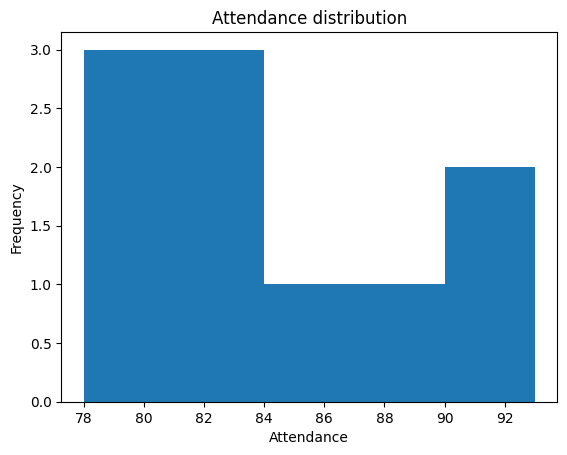

In [10]:
plt.hist(df['Attendance'],bins=5)
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.title("Attendance distribution")
plt.show